In [2]:
from sqlalchemy import create_engine, text
import pandas as pd

In [3]:
cnxn_string = (
    "postgresql+psycopg2://{username}:{pswd}@{host}:{port}/{database}"
)

engine = create_engine(
    cnxn_string.format(
        username="postgres",
        pswd="123456",
        host="localhost",
        port=5432,
        database="chinook"
    )
)

In [4]:
query = """
SELECT billing_country, SUM(total) AS revenue
FROM invoice
GROUP BY billing_country
ORDER BY revenue DESC
"""

df_country = pd.read_sql_query(query, engine)
df_country.head()

,billing_country,revenue
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48


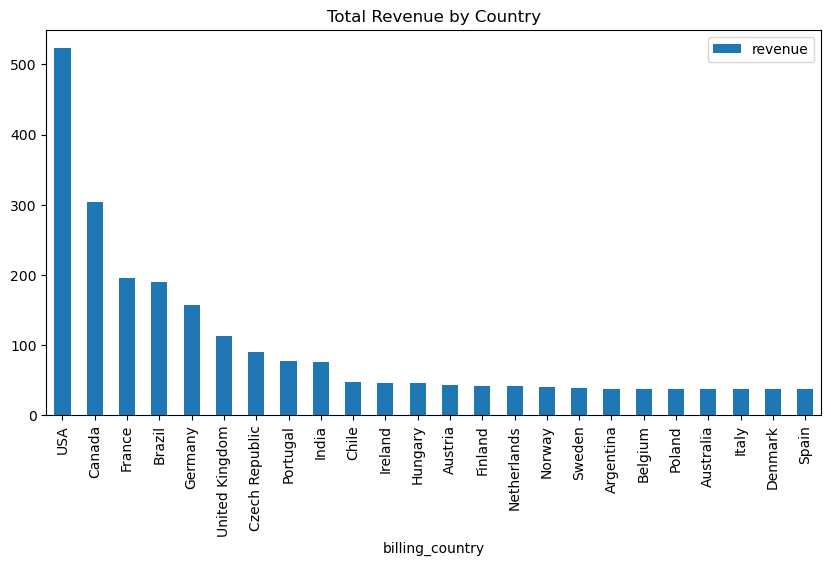

In [5]:
import matplotlib.pyplot as plt

df_country.plot(
    x="billing_country",
    y="revenue",
    kind="bar",
    figsize=(10,5),
    title="Total Revenue by Country"
)

plt.show()

This analysis summarizes total sales revenue by country. The results show that the USA generates the highest revenue, followed by Canada and France. This indicates that North America is the most profitable market for the digital music store. The company can focus its marketing and customer engagement strategies on these key markets to increase revenue.

In [6]:
query = """
SELECT EXTRACT(YEAR FROM invoice_date) AS year,
       SUM(total) AS revenue
FROM invoice
GROUP BY EXTRACT(YEAR FROM invoice_date)
ORDER BY year
"""

df_trend = pd.read_sql(query, engine)
print(df_trend)
df_trend["year"] = df_trend["year"].astype(int)


     year  revenue
0  2021.0   449.46
1  2022.0   481.45
2  2023.0   469.58
3  2024.0   477.53
4  2025.0   450.58


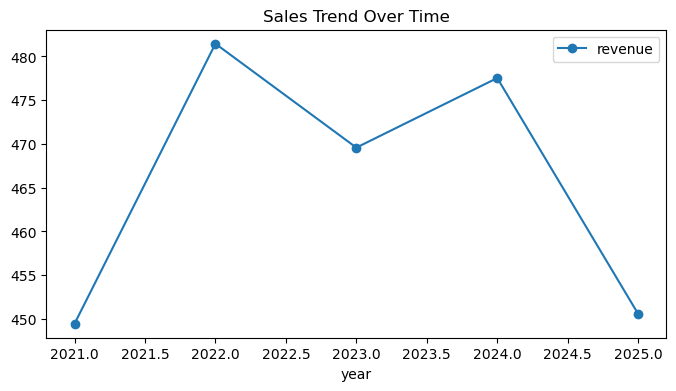

In [7]:
df_trend.plot(
    x="year",
    y="revenue",
    kind="line",
    marker="o",
    figsize=(8,4),
    title="Sales Trend Over Time"
)

plt.show()

This analysis examines the sales trend over time. By analyzing revenue by year, the company can observe how sales performance changes over time. If revenue increases, it may indicate growing customer demand. If revenue decreases, the company may need to improve marketing strategies or product offerings.

In [11]:
query = """
SELECT g.name AS genre, SUM(il.quantity) AS total_sales
FROM genre g
JOIN track t ON g.genre_id = t.genre_id
JOIN invoice_line il ON t.track_id = il.track_id
GROUP BY g.name
ORDER BY total_sales DESC
LIMIT 10
"""

df_genre = pd.read_sql(query, engine)
print(df_genre)

                genre  total_sales
0                Rock          835
1               Latin          386
2               Metal          264
3  Alternative & Punk          244
4                Jazz           80
5               Blues           61
6            TV Shows           47
7           Classical           41
8            R&B/Soul           41
9              Reggae           30


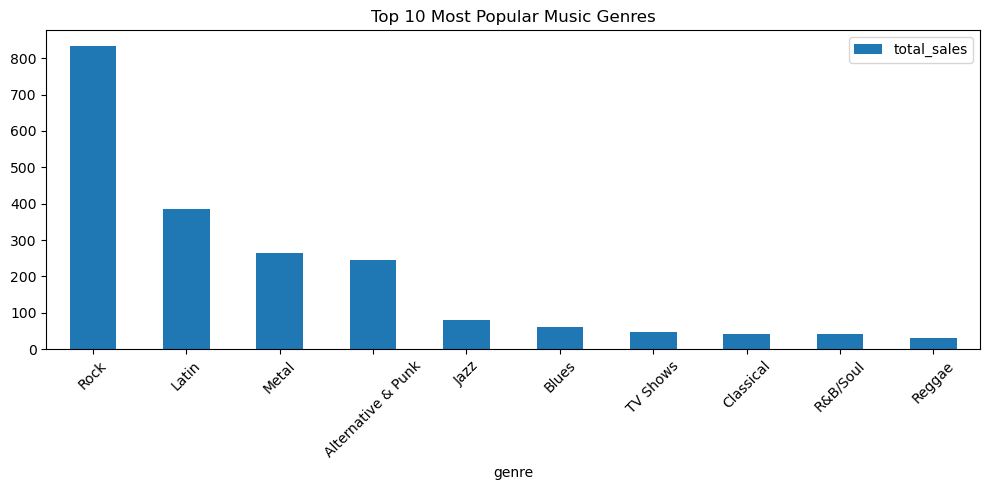

In [12]:
df_genre.plot(
    x="genre",
    y="total_sales",
    kind="bar",
    figsize=(10,5),
    title="Most Popular Music Genres"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This analysis presents the top 10 music genres based on total sales. The results highlight the most popular genres among customers, with Rock leading by a significant margin, followed by Latin and Metal. Understanding these preferences helps the company make informed decisions regarding music catalog expansion, targeted promotions, and marketing strategies.

In [14]:
# 1-Month Before & After Analysis
query_1mo = """
SELECT 
    CASE 
        WHEN invoice_date >= DATE '2023-07-01' - INTERVAL '1 month' 
             AND invoice_date < DATE '2023-07-01' THEN 'Before Update (June)'
        WHEN invoice_date >= DATE '2023-07-01' 
             AND invoice_date < DATE '2023-07-01' + INTERVAL '1 month' THEN 'After Update (July)'
    END AS period,
    SUM(total) AS total_sales
FROM invoice
WHERE invoice_date >= DATE '2023-07-01' - INTERVAL '1 month' 
  AND invoice_date < DATE '2023-07-01' + INTERVAL '1 month'
GROUP BY 
    CASE 
        WHEN invoice_date >= DATE '2023-07-01' - INTERVAL '1 month' 
             AND invoice_date < DATE '2023-07-01' THEN 'Before Update (June)'
        WHEN invoice_date >= DATE '2023-07-01' 
             AND invoice_date < DATE '2023-07-01' + INTERVAL '1 month' THEN 'After Update (July)'
    END
ORDER BY period;
"""
df_1mo = pd.read_sql(query_1mo, engine)
print(df_1mo)


                 period  total_sales
0   After Update (July)        37.62
1  Before Update (June)        50.62


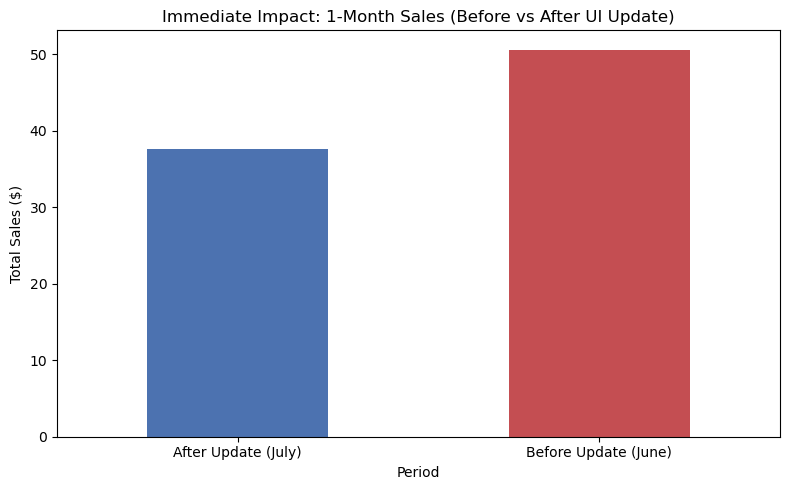

In [15]:
colors_1mo = ['#4C72B0', '#C44E52']

df_1mo.plot(
    x="period", 
    y="total_sales", 
    kind="bar", 
    color=colors_1mo, 
    figsize=(8,5), 
    legend=False,
    title="Immediate Impact: 1-Month Sales (Before vs After UI Update)"
)

plt.ylabel("Total Sales ($)")
plt.xlabel("Period")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
# 3-Month Before & After Analysis
query_3mo = """
SELECT 
    CASE 
        WHEN invoice_date >= DATE '2023-07-01' - INTERVAL '3 months' 
             AND invoice_date < DATE '2023-07-01' THEN 'Before Update (3 Months)'
        WHEN invoice_date >= DATE '2023-07-01' 
             AND invoice_date < DATE '2023-07-01' + INTERVAL '3 months' THEN 'After Update (3 Months)'
    END AS period,
    SUM(total) AS total_sales
FROM invoice
WHERE invoice_date >= DATE '2023-07-01' - INTERVAL '3 months' 
  AND invoice_date < DATE '2023-07-01' + INTERVAL '3 months'
GROUP BY 
    CASE 
        WHEN invoice_date >= DATE '2023-07-01' - INTERVAL '3 months' 
             AND invoice_date < DATE '2023-07-01' THEN 'Before Update (3 Months)'
        WHEN invoice_date >= DATE '2023-07-01' 
             AND invoice_date < DATE '2023-07-01' + INTERVAL '3 months' THEN 'After Update (3 Months)'
    END
ORDER BY period;
"""


df_3mo = pd.read_sql(query_3mo, engine)
print(df_3mo)

                     period  total_sales
0   After Update (3 Months)       112.86
1  Before Update (3 Months)       144.86


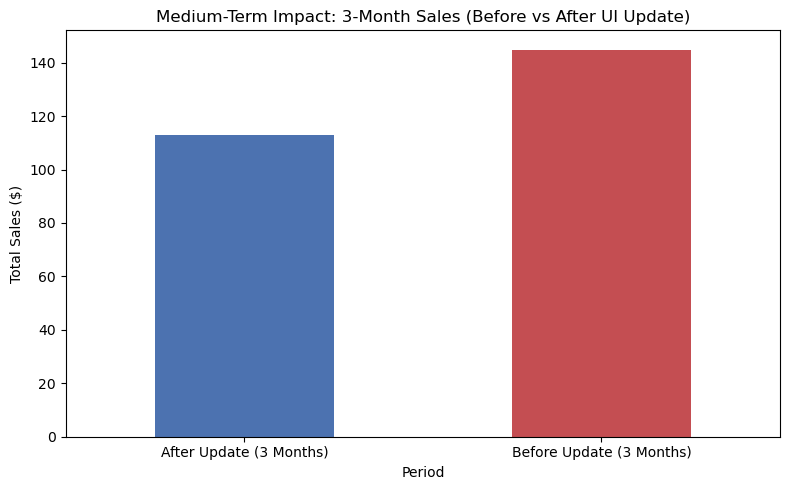

In [17]:
colors_3mo = ['#4C72B0', '#C44E52']

df_3mo.plot(
    x="period", 
    y="total_sales", 
    kind="bar", 
    color=colors_3mo, 
    figsize=(8,5), 
    legend=False,
    title="Medium-Term Impact: 3-Month Sales (Before vs After UI Update)"
)

plt.ylabel("Total Sales ($)")
plt.xlabel("Period")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()